In [47]:
#import necessary package
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from PIL import Image

In [49]:
print(torch.__version__)
# Define hyperparameters
batch_size = 64
learning_rate = 0.01
num_epochs = 10
# load MNIST dataset from torchvision
# Define the transformation to convert image to tensor
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
    ])

# load MNIST dataset from torchvision with defined transformation
train_MNIST = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_MNIST = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Create data loader to load the dataset in batches
train_loader = torch.utils.data.DataLoader(train_MNIST, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_MNIST, batch_size=batch_size, shuffle=False)

1.13.1+cpu


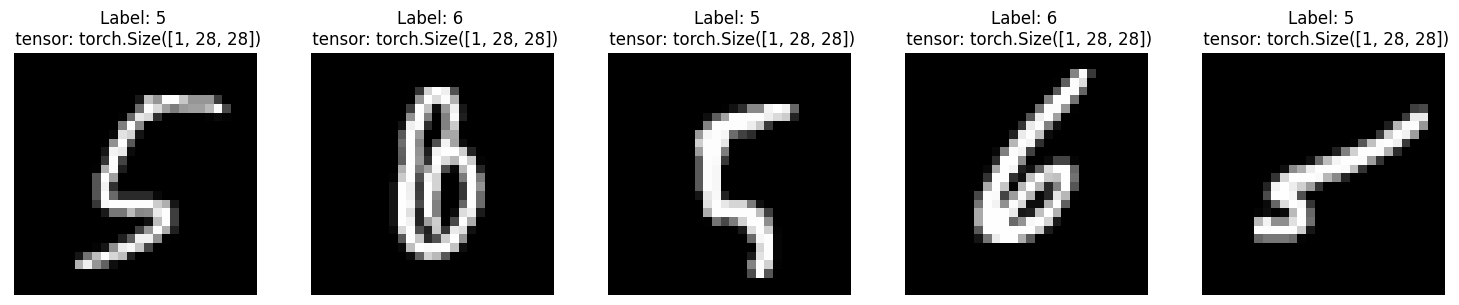

In [50]:
# Create a figure to display the images
plt.figure(figsize=(15, 3))

# Print the first few images in a row
for i, (image, label) in enumerate(train_loader):
    if i < 5:  # Print the first 5 samples
        plt.subplot(1, 5, i + 1)
        plt.imshow(image[0].squeeze(), cmap='gray')
        plt.title(f"Label: {label[0].item()} \n tensor: {image[0].shape}")
        plt.axis('off')
    else:
        break  # Exit the loop after printing 5 samples

plt.tight_layout()
plt.show()

In [52]:
# Build Neural Network 3 hidden layers, 256 nodes/L1, 128 nodes/L2 and 64 nodes/L3
# Define the image classifier model
class ImageClassifier(nn.Module):
    def __init__(self):
        super(ImageClassifier, self).__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),              # 28x28 → 784

            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)          # 10 classes
        )

    def forward(self, x):
        return self.model(x)
ImageClassifier()

ImageClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [53]:
# Create an instance of the image classifier model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImageClassifier().to(device)

In [54]:
# Define the optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
# evaluate function
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [55]:
# Train the model
for epoch in range(10):  # Train for 10 epochs
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = loss_fn(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        running_loss += loss.item()
        # accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    # acc = evaluate(model, test_loader, device)
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader):.4f}, Accuracy: {train_acc:.4f}")

Epoch 1, Loss: 0.2842, Accuracy: 91.4833
Epoch 2, Loss: 0.1368, Accuracy: 95.7667
Epoch 3, Loss: 0.1107, Accuracy: 96.5483
Epoch 4, Loss: 0.0949, Accuracy: 97.0117
Epoch 5, Loss: 0.0826, Accuracy: 97.3333
Epoch 6, Loss: 0.0726, Accuracy: 97.6567
Epoch 7, Loss: 0.0678, Accuracy: 97.8100
Epoch 8, Loss: 0.0595, Accuracy: 98.0883
Epoch 9, Loss: 0.0571, Accuracy: 98.1467
Epoch 10, Loss: 0.0529, Accuracy: 98.2400


In [56]:
model.eval()
correct = 0
total = 0

val_acc = evaluate(model, test_loader, device)

print(f"Test Accuracy: {val_acc:.2f}%")

Test Accuracy: 98.04%


In [57]:
# Save the trained model
torch.save(model.state_dict(), 'MNIST_Classifier.pt')

In [ ]:
# Load the saved model
with open('model_state.pt', 'rb') as f: 
     model.load_state_dict(torch.load(f))  

In [75]:
# Create a figure to display the images
plt.figure(figsize=(15, 3))

# Print the first few images in a row
index = 2
image, label = test_loader[0]
plt.subplot(1, 1, 1)
plt.imshow(image[index].squeeze(), cmap='gray')
plt.title(f"Label: {label[0].item()} \n tensor: {image[0].shape}")
plt.axis('off')
# img_tensor = transform(image[0]).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model(image[index])
    predicted_label = torch.argmax(output, dim=1)
print(output)
print(f"Predicted label: {predicted_label.item()}")

plt.tight_layout()
plt.show()

TypeError: 'DataLoader' object is not subscriptable

<Figure size 1500x300 with 0 Axes>

In [83]:
# Perform inference on an image
# img = Image.open('number5.png').convert("L")
img = Image.open('number5.png')
img_tensor = transform(img).unsqueeze(0).to(device)
# If digit is dark on white background → invert
# img_tensor = 1.0 - img_tensor
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    predicted_label = torch.argmax(output, dim=1)
print(output)
print(f"Predicted label: {predicted_label.item()}")
plt.subplot(1, 1, 1)
plt.imshow(img_tensor.squeeze(), cmap='gray')
plt.title(f"tensor: {img_tensor.shape}")
plt.axis('off')
plt.tight_layout()
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x3136 and 784x256)